# Buffett's Alpha A股：大盘定义（已锁定）

大盘 = 总市值>300亿 + 300亿内近60日累计成交金额前300 + 近7日均成交金额≥2亿。

In [1]:
import os, sys, warnings
from pathlib import Path
import pandas as pd, numpy as np
from IPython.display import display
warnings.filterwarnings('ignore')
_ROOT = Path.cwd().resolve()
while not (_ROOT / 'pyproject.toml').exists(): _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT))
from strategy.buffetts_alpha import (
    CAP_FLOOR, AMT7_FLOOR, amounts, big_pool, value_rank, gated_pool,
    add_composite, select_topN, quarter_dates, run_full,
)
from strategy.graham_dodd import load_universe, load_market, load_index, snapshot, trading_days
from backtest.metrics import performance_summary
D = pd.Timestamp('2024-07-01')
df = big_pool(D)
fun = df.attrs['funnel']
print(D.date(), fun, '大盘=', len(df)); display(df.head(10))

2024-07-01 {'n': 5904, 'notrad': 1865, 'cap': 3731} 大盘= 237


,code,name,industry,cap,amt60,amt7
36,000906,浙商中拓,商业百货,2.605545e+12,6.116405e+15,7.884892e+13
35,000905,厦门港务,交通运输,3.711393e+12,3.910298e+15,4.712859e+13
195,600519,贵州茅台,酿酒行业,1.809402e+12,3.006404e+11,5.949534e+09
249,601127,赛力斯,,1.393982e+11,2.555572e+11,5.496070e+09
250,601138,工业富联,,5.561928e+11,2.369668e+11,3.166507e+09
125,300750,宁德时代,,7.745392e+11,2.313485e+11,3.144597e+09
112,300308,中际旭创,机械行业,1.163295e+11,2.162095e+11,3.336146e+09
289,601899,紫金矿业,有色金属,4.748263e+10,1.967528e+11,2.144235e+09
298,603259,药明康德,,1.134025e+11,1.866698e+11,1.297667e+09
91,002594,比亚迪,汽车制造,7.184701e+11,1.794872e+11,3.001779e+09


## 便宜定义：大盘内 E/P+B/P+D/P 等权 z，硬门 E/P>0.02 且 B/P<2，周期排除。

In [2]:
val, vfun = value_rank(D, df['code'])
print('价值池=', len(val), vfun); display(val.head(10))

价值池= 103 {'cyc': 104, 'neg': 8, 'cheap': 22}


,code,name,industry,ep,bp,dp,value_z
0,600048,保利发展,房地产,0.166094,1.794883,0.048335,1.628872
1,002459,晶澳科技,机械行业,0.197836,0.933537,0.050044,1.573089
2,600256,广汇能源,综合行业,0.270504,0.664216,0.102489,1.539619
3,601607,上海医药,商业百货,0.081981,0.976201,0.031476,1.394582
4,000661,长春高新,生物制药,0.102260,0.605112,0.048237,1.338799
5,601012,隆基绿能,电子器件,0.148257,0.640047,0.028470,1.271859
6,600863,华能蒙电,电力行业,0.068950,0.624324,0.034599,1.216076
7,002304,洋河股份,酿酒行业,0.083707,0.477838,0.057845,1.160292
8,000651,格力电器,家电行业,0.112354,0.554776,0.025707,1.071039
9,000625,长安汽车,汽车制造,0.075979,0.543685,0.025258,0.970629


In [3]:
dys = pd.Series({c: snapshot(c, D).dividend_yield for c in df['code']})
print(dys.describe(percentiles=[.1,.25,.5,.75,.9]).round(4))
print('>4%:', int((dys > 0.04).sum()), '>3%:', int((dys > 0.03).sum()), '缺失:', int(dys.isna().sum()))
print(val[['code','name','industry','ep','bp','dp','value_z']].to_string(index=False))

count    219.0000
mean       0.0210
std        0.0181
min        0.0000
10%        0.0038
25%        0.0086
50%        0.0170
75%        0.0264
90%        0.0455
max        0.1129
dtype: float64
>4%: 28 >3%: 42 缺失: 18
  code  name industry       ep       bp       dp   value_z
600048  保利发展      房地产 0.166094 1.794883 0.048335  1.628872
002459  晶澳科技     机械行业 0.197836 0.933537 0.050044  1.573089
600256  广汇能源     综合行业 0.270504 0.664216 0.102489  1.539619
601607  上海医药     商业百货 0.081981 0.976201 0.031476  1.394582
000661  长春高新     生物制药 0.102260 0.605112 0.048237  1.338799
601012  隆基绿能     电子器件 0.148257 0.640047 0.028470  1.271859
600863  华能蒙电     电力行业 0.068950 0.624324 0.034599  1.216076
002304  洋河股份     酿酒行业 0.083707 0.477838 0.057845  1.160292
000651  格力电器     家电行业 0.112354 0.554776 0.025707  1.071039
000625  长安汽车     汽车制造 0.075979 0.543685 0.025258  0.970629
600089  特变电工     发电设备 0.248476 0.937861 0.014327  0.959473
600060  海信视像     家电行业 0.061053 0.583369 0.025647  0.948316
000999  华润三九   

## 三支柱宽松硬门：便宜 + 收缩 Beta<1.5 + 股息>3%或ROE>10%。

In [4]:
pool, funnel = gated_pool(D, df['code'])
print('三门后=', len(pool), funnel)

三门后= 63 {'cyc': 104, 'neg': 8, 'cheap': 22, 'beta': 8, 'qual': 32}


In [5]:
top30 = add_composite(pool, D).head(30).reset_index(drop=True)
print(top30[['code','name','industry','composite','value_z','safe_z','quality_z']].to_string(index=False))

  code  name industry  composite   value_z    safe_z  quality_z
600256  广汇能源     综合行业   1.188075  1.563895  0.436436   1.563895
600863  华能蒙电     电力行业   1.042597  1.109274  1.527525   0.490990
600642  申能股份     电力行业   0.854687  0.654654  1.582080   0.327327
000333  美的集团     家电行业   0.848625  0.854687  1.309307   0.381881
000408  藏格矿业     商业百货   0.818317  0.818317  0.218218   1.418416
000999  华润三九     生物制药   0.818317  0.854687  1.472971   0.127294
000651  格力电器     家电行业   0.763763  0.963796  1.091089   0.236403
601607  上海医药     商业百货   0.745578  1.218383  1.036535  -0.018185
600887  伊利股份     食品行业   0.612222  0.709208  0.927426   0.200033
600660  福耀玻璃     汽车制造   0.563730 -0.090924  1.363862   0.418251
600089  特变电工     发电设备   0.563730  0.836502  0.109109   0.745578
600674  川投能源     电力行业   0.478867  0.127294  1.636634  -0.327327
600060  海信视像     家电行业   0.466744  0.763763  0.545545   0.090924
002459  晶澳科技     机械行业   0.466744  1.527525 -1.582080   1.454786
002304  洋河股份     酿酒行业   0.460682  1.1820

In [6]:
top20 = select_topN(D)
print(len(top20)); print(top20[['code','name','industry','composite']].to_string(index=False))

20
  code name industry  composite
600256 广汇能源     综合行业   1.188075
600863 华能蒙电     电力行业   1.042597
600642 申能股份     电力行业   0.854687
000333 美的集团     家电行业   0.848625
000408 藏格矿业     商业百货   0.818317
000999 华润三九     生物制药   0.818317
000651 格力电器     家电行业   0.763763
601607 上海医药     商业百货   0.745578
600887 伊利股份     食品行业   0.612222
600660 福耀玻璃     汽车制造   0.563730
600089 特变电工     发电设备   0.563730
600674 川投能源     电力行业   0.478867
600060 海信视像     家电行业   0.466744
002459 晶澳科技     机械行业   0.466744
002304 洋河股份     酿酒行业   0.460682
000661 长春高新     生物制药   0.363696
002422 科伦药业     生物制药   0.357635
000921 海信家电     家电行业   0.351573
000538 云南白药     生物制药   0.351573
600900 长江电力     电力行业   0.339450


## 季度全换回测：50万，5%等权建仓，D+1成交，单股超过10%砍回5%。

In [7]:
from strategy.buffetts_alpha import select_topN
from strategy.graham_dodd import GrahamBacktest, buy_fee, sell_fee, Pos
CAL = trading_days()
D0 = pd.Timestamp('2024-07-01')
Q1 = pd.Timestamp(CAL[CAL >= pd.Timestamp('2024-10-01')][0])
single_maps = [select_topN(D0)]
nav_single, poss_single, trims_single, _ = run_full(
    D0, Q1, capital=500000.0, maps=single_maps, dates=[D0])
print('建仓', len(poss_single), '只 trims=', trims_single,
      '起始%.0f 期末%.0f 收益%.2f%%' % (nav_single.iloc[0], nav_single.iloc[-1], nav_single.iloc[-1] / nav_single.iloc[0] * 100 - 100))

建仓 20 只 trims= 0 起始499856 期末568366 收益13.71%


In [8]:
import multiprocessing as mp
START = pd.Timestamp('2023-07-01')
HARD_END = min(pd.Timestamp('2026-09-19'), CAL.max())
qs = quarter_dates(START, HARD_END)
print('调仓日:', [d.date().isoformat() for d in qs])
with mp.get_context('fork').Pool(8) as pool:
    maps = pool.map(select_topN, qs)
print('各期入选:', [len(m) for m in maps])
nav, poss, ntrim, _ = run_full(START, HARD_END, capital=500000.0, maps=maps)
print('期末%.0f trims=%d' % (nav.iloc[-1], ntrim))

调仓日: ['2023-07-03', '2023-10-09', '2024-01-02', '2024-04-01', '2024-07-01', '2024-10-08', '2025-01-02', '2025-04-01', '2025-07-01', '2025-10-09', '2026-01-05', '2026-04-01', '2026-07-01']


各期入选: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


期末424599 trims=0


In [9]:
print(performance_summary(nav.pct_change().dropna(), nav))
b60 = load_index('000300')['close'].reindex(nav.index).ffill()
b80 = load_index('000906')['close'].reindex(nav.index).ffill()
cmp = pd.DataFrame({'策略': nav, '沪深300': b60 / b60.iloc[0] * nav.iloc[0],
                    '中证800': b80 / b80.iloc[0] * nav.iloc[0]})
print(cmp.iloc[[0, len(cmp)//2, -1]].round(0))

{'annual_return': np.float64(-0.05128723596194129), 'annual_vol': np.float64(0.14540149399752422), 'sharpe': np.float64(-0.49027856593519675), 'sortino': np.float64(-0.7047353960587304), 'calmar': np.float64(-0.2976580062228135), 'max_drawdown': np.float64(-0.23949376288094482), 'win_rate': np.float64(0.4647887323943662), 'cumulative_return': np.float64(-0.15055384996253296), 'rf_used': 0.02}
                  策略     沪深300     中证800
2023-07-04  499854.0  499854.0  499854.0
2025-02-17  471147.0  506057.0  502053.0
2026-09-18  424599.0  577848.0  614323.0


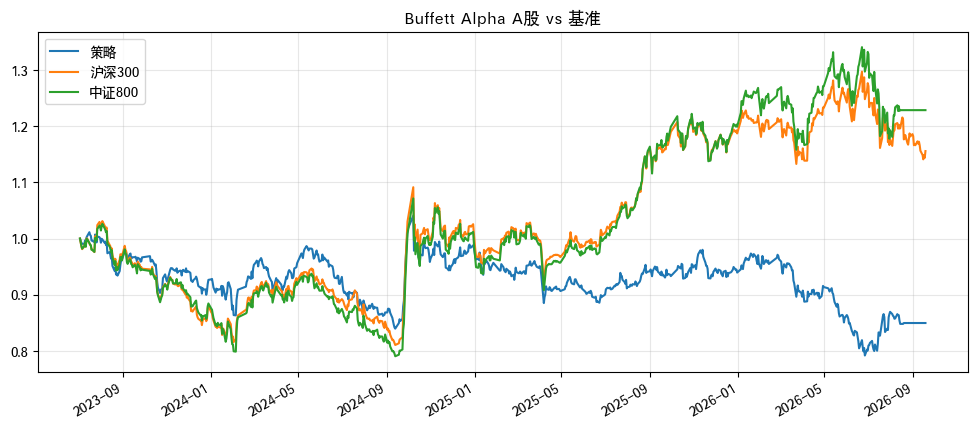

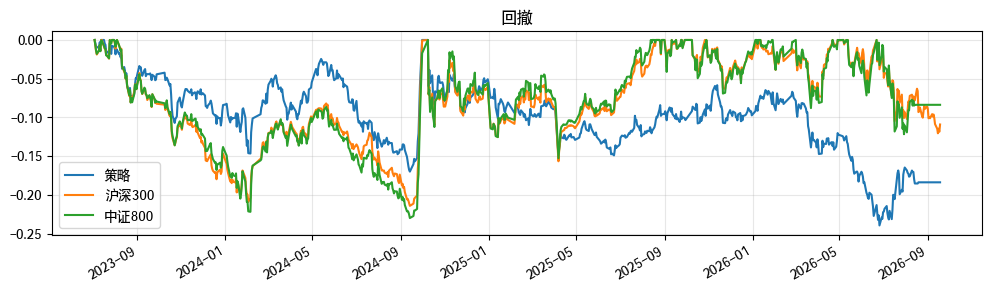

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Hei', 'Heiti TC', 'STHeiti', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
norm = cmp.div(cmp.iloc[0])
fig, ax = plt.subplots(figsize=(12, 5)); norm.plot(ax=ax)
ax.set_title('Buffett Alpha A股 vs 基准'); ax.grid(True, alpha=.3); plt.show()
(norm.div(norm.cummax()) - 1).plot(figsize=(12, 3), title='回撤')
plt.grid(True, alpha=.3); plt.show()